In [1]:
import sys
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from tqdm.auto import tqdm

**确定参数**

**导入并整理数据**

In [2]:
股票代码 = '000625'
start_date = "20240607"
end_date = '20250328'
split_ratio = 0.7
mean_reversion_params = None

source_data = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='hfq')

data = pd.DataFrame()
data['date'] = source_data['日期']
data['price'] = source_data['收盘']
data['volume'] = source_data['成交量']
data['returns']=np.log(data['price']/data['price'].shift(1))
data['returns_cum'] = np.exp(data['returns'].cumsum())
data.set_index('date', inplace=True)
data.dropna()

,price,volume,returns,returns_cum
date,,,,
2024-06-11,124.01,1071214,-0.000645,0.999355
2024-06-12,124.64,833636,0.005067,1.004432
2024-06-13,124.56,1155122,-0.000642,1.003788
2024-06-14,125.91,1206829,0.010780,1.014667
2024-06-17,129.40,2148599,0.027341,1.042792
...,...,...,...,...
2025-03-24,120.84,679121,-0.000579,0.973809
2025-03-25,120.60,438565,-0.001988,0.971875
2025-03-26,121.07,474144,0.003890,0.975663


**分割训练集**

In [3]:
total_dates = data.index.nunique()
split_index = int(total_dates *split_ratio)
split_date = data.index.unique()[split_index]
train = data[:split_date].copy()
test = data[split_date:].copy()

**构建函数**

**策略jisuan**

In [4]:
def automas_by_mean(df, window_size, decay_factor, Default_Strategy, mean_reversion_params=None):
    """
    结合动量策略和均值回归策略的自动交易系统
    修改后的组合策略在均值回归信号为0时只使用动量策略信号
    """

    # 2. 动量策略部分
    for days in range(1, 23):
        df[f'position_{days}d'] = np.where(df['returns'].rolling(days).mean() > 0, 1, 0)
        df[f'strategy_{days}d'] = df[f'position_{days}d'].shift(1) * df['returns']
        df[f'sty_cumr_{days}d'] = df[f'strategy_{days}d'].cumsum() + 1
    
    # 3. 均值回归策略部分
    sma_window = mean_reversion_params['sma_window']
    threshold = mean_reversion_params['threshold']
    position_col = mean_reversion_params['position_col']
    
    df['SMA'] = df['price'].rolling(sma_window).mean()
    df['distance'] = df['price'] - df['SMA']
    
    df[position_col] = np.nan
    df[position_col] = np.where(
        (df['distance'] >= threshold) | (df['returns'].rolling(5).mean() < -0.02),  # 增加动量止盈条件
        0,  # 卖出信号：高估或动量转弱时空仓
        np.where(
            df['distance'] <= -threshold,
            1,  # 买入信号：低估时做多
            df[position_col]  # 保持原有仓位
        )
    )
    df[position_col] = df[position_col].fillna(0)
    
    df['mean_reversion_returns'] = df[position_col].shift(1) * df['returns']
    
    # 4. 动量策略选择部分
    strategy_return_columns = [f'strategy_{days}d' for days in range(1, 23)]
    all_strategy_returns = df[strategy_return_columns].copy()
    
    weights = np.array([decay_factor ** (window_size - i - 1) for i in range(window_size)])
    weights = weights / weights.sum()
    
    best_strategy_by_mean_return = []
    
    for i in range(len(all_strategy_returns)):
        if i < window_size:
            current_window = all_strategy_returns.iloc[:i+1]
            current_weights = weights[window_size - (i+1):]
            current_weights = current_weights / current_weights.sum()
        else:
            current_window = all_strategy_returns.iloc[i-window_size:i]
            current_weights = weights
        
        if not current_window.empty:
            mean_returns = (current_window * current_weights[:, np.newaxis]).sum()
            best_strat = mean_returns.idxmax()
        else:
            best_strat = Default_Strategy
        best_strategy_by_mean_return.append(best_strat)
    
    df['best_strategy_mean_return'] = best_strategy_by_mean_return
    
    # 5. 应用最佳动量策略
    df['auto_strategy_mean_return_position'] = np.nan
    
    for days in range(1, 23):
        mask = df['best_strategy_mean_return'] == f'strategy_{days}d'
        df.loc[mask, 'auto_strategy_mean_return_position'] = df.loc[mask, f'position_{days}d']
        df.loc[mask, 'auto_strategy_mean_return'] = df.loc[mask, 'returns'] * df[f'position_{days}d'].shift(1)

    # 6. 修改后的组合策略 - 只在均值回归有信号时使用    
    # 确保组合策略计算正确（当mean_rev信号为0时完全等于动量策略）
    df['combined_position'] = df['combined_position'] = np.where(
        df[position_col].shift(1) != 0, 
        df[position_col].shift(1), 
        df['auto_strategy_mean_return_position']
    )
    
    # 强制限制仓位范围
    df['combined_position'] = np.clip(df['combined_position'], 0, 1) 

    df['combined_returns'] = df['mean_reversion_returns'].shift(1).copy()
    mask = df[position_col].shift(1) == 0
    df.loc[mask, 'combined_returns'] = df.loc[mask, 'auto_strategy_mean_return']

    # 7. 返回结果
    return df[[
        'auto_strategy_mean_return_position', 
        position_col, 
        'combined_position', 
        'auto_strategy_mean_return', 
        'mean_reversion_returns', 
        'combined_returns',
    ]]

**策略表现**

In [5]:
def gra_analyze(df):
    # Set English fonts and style
    plt.style.use('seaborn-v0_8')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False
    
     
    # ======================
    # 0. 新增：价格与移动平均线距离图
    # ======================
    plt.figure(figsize=(25, 6))
    
    # 计算SMA和距离（如果尚未计算）
    if 'SMA' not in df.columns:
        df['SMA'] = df['price'].rolling(mean_reversion_params['sma_window']).mean()
    if 'distance' not in df.columns:
        df['distance'] = df['price'] - df['SMA']
    
    # 绘制距离线
    df['distance'].dropna().plot(label='Price - SMA Distance', color='blue')
    
    # 绘制阈值线
    plt.axhline(mean_reversion_params['threshold'], color='red', linestyle='--', label='Upper Threshold')
    plt.axhline(-mean_reversion_params['threshold'], color='red', linestyle='--', label='Lower Threshold')
    plt.axhline(0, color='black', linestyle='-', alpha=0.5, label='SMA Line')
    
    # 标记交易信号点
    buy_signals = df[df['mean_reversion_position'] == 1]
    sell_signals = df[df['mean_reversion_position'] == 0]
    
    plt.scatter(buy_signals.index, buy_signals['distance'], 
               color='green', marker='^', s=100, label='Buy Signal')
    plt.scatter(sell_signals.index, sell_signals['distance'],
               color='red', marker='v', s=100, label='Sell Signal')
    
    plt.title('Price-SMA Distance with Trading Signals')
    plt.ylabel('Distance from SMA')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 1. Trading Position Plots (for all three strategies)
    # ======================
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(25, 9), sharex=True)
    
    # Momentum strategy position
    ax1.plot(df['auto_strategy_mean_return_position'], color='blue')
    ax1.set_title('Momentum Strategy Position (1=Long, -1=Short)')
    ax1.set_ylabel('Position')
    ax1.set_ylim([-1.1, 1.1])
    ax1.grid(True)
    
    # Mean reversion strategy position
    ax2.plot(df['mean_reversion_position'], color='green')
    ax2.set_title('Mean Reversion Strategy Position (1=Long, -1=Short)')
    ax2.set_ylabel('Position')
    ax2.set_ylim([-1.1, 1.1])
    ax2.grid(True)
    
    # Combined strategy position
    ax3.plot(df['combined_position'], color='purple')
    ax3.set_title('Combined Strategy Position')
    ax3.set_ylabel('Position')
    ax3.set_ylim([-1.1, 1.1])
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 2. Performance Metrics (for all three strategies)
    # ======================
    metrics = pd.DataFrame()
    
    # Calculate metrics for each strategy
    strategies = {
        'Momentum': 'auto_strategy_mean_return',
        'MeanReversion': 'mean_reversion_returns',
        'Combined': 'combined_returns'
    }
    
    for name, col in strategies.items():
        mean_return = df[col].mean()
        std_dev = df[col].std()
        
        metrics.loc[name, 'Mean'] = mean_return
        metrics.loc[name, 'StdDev'] = std_dev
        
        # 修正Sharpe比率的计算方式
        if std_dev != 0:  # 直接比较标量值而不是Series
            metrics.loc[name, 'Sharpe'] = mean_return / std_dev
        else:
            metrics.loc[name, 'Sharpe'] = np.nan
            
        metrics.loc[name, 'TotalReturn'] = df[col].sum()
        
        # Calculate max drawdown
        cumret = df[col].cumsum().apply(np.exp)
        cummax = cumret.cummax()
        max_drawdown = (cummax - cumret).max()
        metrics.loc[name, 'MaxDrawdown'] = max_drawdown
    
    # ======================
    # 3. Price/Volume Plots (using combined strategy signals)
    # ======================
    # Use threshold to determine clear signals
    buy = df[df['combined_position'] >= 1]  # Strong long signals
    sell = df[df['combined_position'] <= -1]  # Strong short signals
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(25, 12))
    
    # Price plot
    ax1.plot(df['price'], label='Price', color='black', alpha=0.8)
    ax1.scatter(buy.index, buy['price'], color='red', label='Buy Signal (Combined)', marker='^', s=100)
    ax1.scatter(sell.index, sell['price'], color='green', label='Sell Signal (Combined)', marker='v', s=100)
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Volume plot
    ax2.bar(df.index, df['volume'], color='gray', alpha=0.3, label='Volume')
    ax2.bar(buy.index, buy['volume'], color='red', label='Buy Volume')
    ax2.bar(sell.index, sell['volume'], color='green', label='Sell Volume')
    ax2.set_ylabel('Volume')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle('Price and Volume with Combined Strategy Signals', y=0.92)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 4. Cumulative Returns Comparison
    # ======================
    plt.figure(figsize=(25, 8))
    
    # Calculate cumulative returns
    df['momentum_cumret'] = df['auto_strategy_mean_return'].cumsum().apply(np.exp)
    df['meanrev_cumret'] = df['mean_reversion_returns'].cumsum().apply(np.exp)
    df['combined_cumret'] = df['combined_returns'].cumsum().apply(np.exp)
    df['buyhold_cumret'] = df['returns'].cumsum().apply(np.exp)
    
    plt.plot(df['momentum_cumret'], label='Momentum Strategy', color='blue')
    plt.plot(df['meanrev_cumret'], label='Mean Reversion Strategy', color='green')
    plt.plot(df['combined_cumret'], label='Combined Strategy', color='purple', linewidth=3)
    plt.plot(df['buyhold_cumret'], label='Buy & Hold', color='gray', linestyle='--')
    
    plt.title('Cumulative Returns Comparison')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 5. Comprehensive Strategy Comparison
    # ======================
    plt.figure(figsize=(25, 12))
    
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    
    # Price plot
    ax1.plot(df['price'], label='Price', color='black', alpha=0.7)
    
    # Strategy returns
    ax2.plot(df['combined_cumret'], 
             label='Combined Strategy', 
             color='purple',
             linewidth=3,
             zorder=3)
    
    ax2.plot(df['momentum_cumret'], 
             label='Momentum Strategy', 
             color='blue',
             linewidth=2,
             linestyle='--',
             alpha=0.7,
             zorder=2)
    
    ax2.plot(df['meanrev_cumret'], 
             label='Mean Reversion Strategy', 
             color='green',
             linewidth=2,
             linestyle=':',
             alpha=0.7,
             zorder=2)
    
    # Trading zones based on combined strategy
    ax1.fill_between(df.index, 
                    df['price'].min()*0.98, 
                    df['price'].max()*1.02,
                    where=(df['combined_position']>0),
                    color='green', alpha=0.05, label='Long Zone')
    ax1.fill_between(df.index,
                     df['price'].min()*0.98,
                     df['price'].max()*1.02,
                     where=(df['combined_position']<0),
                     color='red', alpha=0.05, label='Short Zone')
    
    ax1.set_ylabel('Price')
    ax2.set_ylabel('Cumulative Returns')
    
    plt.title('Comprehensive Strategy Performance Comparison', pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Combine legends
    handles, labels = [], []
    for ax in [ax1, ax2]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    plt.legend(handles, labels, loc='upper left', ncol=3)
    
    plt.tight_layout()
    plt.show()

    # ======================
    # 6. NEW: Drawdown Analysis Plot (Added as requested)
    # ======================
    plt.figure(figsize=(25, 8))
    
    # Calculate cumulative max for combined strategy
    df['cumret'] = df['combined_returns'].cumsum().apply(np.exp)
    df['cummax'] = df['cumret'].cummax()
    
    # Plot both lines
    df[['cumret', 'cummax']].plot()
    
    # Highlight drawdown areas
    plt.fill_between(df.index, 
                    df['cumret'], 
                    df['cummax'],
                    where=(df['cumret'] < df['cummax']),
                    color='red', alpha=0.3)
    
    plt.title('Cumulative Returns vs Peak Returns (Drawdown Analysis)')
    plt.ylabel('Returns')
    plt.legend(['Cumulative Returns', 'Peak Returns'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 7. Performance Metrics Display
    # ======================
    print("\nPerformance Metrics:")
    print(metrics.round(4))

**操盘指引**

In [6]:
def action(df, last_n_days=5):
    """
    绘制自适应纵坐标的交易信号图
    参数：
        df: 包含price和combined_position的DataFrame
        last_n_days: 显示最近N天的数据
    """
    # 提取信号数据
    last_signals = df[['price', 'combined_position']].tail(last_n_days).copy()
    
    # 计算动态纵坐标范围（价格±5%的缓冲空间）
    ymin = last_signals['price'].min() * 0.95
    ymax = last_signals['price'].max() * 1.05
    yrange = ymax - ymin
    
    # 标记信号类型（改进版）
    last_signals['position_change'] = last_signals['combined_position'].diff()
    last_signals['signal'] = np.where(
        (last_signals['position_change'] > 0) & (last_signals['combined_position'] > 0), 
        'BUY',
        np.where(
            (last_signals['position_change'] < 0) & (last_signals['combined_position'] == 0),
            'SELL',
            np.where(
                last_signals['combined_position'] > 0,
                'HOLD',
                'NEUTRAL'
            )
        )
    )
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 绘制价格线（带标记点）
    price_line = plt.plot(last_signals.index, 
                         last_signals['price'], 
                         label='Price', 
                         color='black', 
                         marker='o',
                         markersize=8,
                         linewidth=2)
    
    # 标记买卖信号点
    buy_signals = last_signals[last_signals['signal'] == 'BUY']
    sell_signals = last_signals[last_signals['signal'] == 'SELL']
    
    plt.scatter(buy_signals.index, 
               buy_signals['price'], 
               color='red', 
               label='Buy Signal', 
               marker='^', 
               s=150,
               zorder=3)
    plt.scatter(sell_signals.index,
               sell_signals['price'],
               color='green',
               label='Sell Signal',
               marker='v',
               s=150,
               zorder=3)
    
    # 添加持仓状态背景色
    plt.fill_between(last_signals.index,
                   ymin,
                   ymax,
                   where=(last_signals['combined_position'] > 0),
                   color='green', alpha=0.08, label='Long Zone')
    plt.fill_between(last_signals.index,
                   ymin,
                   ymax,
                   where=(last_signals['combined_position'] < 0),
                   color='red', alpha=0.08, label='Short Zone')
    
    # 动态调整图形细节
    plt.ylim(ymin, ymax)
    plt.yticks(np.arange(ymin, ymax + yrange*0.05, yrange/10))  # 自动生成刻度
    
    # 添加标注
    for date, row in last_signals.iterrows():
        plt.text(date, 
                row['price'] - yrange*0.03,  # 动态调整标注位置
                f"{row['signal']}\nPos:{int(row['combined_position'])}",
                ha='center', 
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.8))
    
    # 美化图形
    plt.title(f"Last {last_n_days} Days Trading Signals (Auto-scaled)", pad=20)
    plt.ylabel("Price", labelpad=10)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', ncol=3)
    plt.tight_layout()
    
    # 显示表格数据
    print("\n最后{}日交易指令：".format(last_n_days))
    display(last_signals[['price', 'combined_position', 'signal']])

    yrange = ymax - ymin
    plt.yticks(np.arange(ymin, ymax + yrange*0.05, yrange/10))
    
    plt.show()

**参数优化**

**动量参数优化**

In [7]:
def optimize_momentum(train_data, n_calls=30):
    """优化动量策略相关参数"""
    space = [
        Integer(20, 50, name='window_size'),
        Real(0.8, 1.2, name='decay_factor'),
        Categorical([f'strategy_{d}d' for d in range(1, 23)], name='Default_Strategy')
    ]
    
    pbar = tqdm(total=n_calls, desc="动量策略优化")
    best_score = -np.inf
    best_params = None
    
    def callback(res):
        nonlocal best_score, best_params
        current_score = -res.fun
        if current_score > best_score:
            best_score = current_score
            best_params = dict(zip(['window_size', 'decay_factor', 'Default_Strategy'], res.x))
        pbar.update(1)
        pbar.set_postfix({'最佳夏普': f"{best_score:.3f}", '策略': best_params['Default_Strategy'] if best_params else None})
    
    def objective(params):
        w_size, decay, default = params
        try:
            # 深拷贝防止数据污染
            df = train_data.copy(deep=True)
            
            # 生成所有策略（但不使用均值回归）
            for d in range(1, 24):
                df[f'position_{d}d'] = np.where(df['returns'].rolling(d).mean() > 0, 1, -1)
                df[f'strategy_{d}d'] = df[f'position_{d}d'].shift(1) * df['returns']
            
            # 获取当前策略表现
            returns = df[default].dropna()
            if len(returns) < 10:
                return 1000
                
            sharpe = returns.mean() / returns.std()
            return -sharpe
            
        except Exception as e:
            print(f"动量参数错误: {params}")
            print(f"错误详情: {type(e).__name__}: {str(e)}")
            return 1000
    
    res = gp_minimize(objective, space, n_calls=n_calls, callback=callback, random_state=42)
    pbar.close()
    
    momentum_params = {
        'window_size': int(best_params['window_size']),
        'decay_factor': float(best_params['decay_factor']),
        'Default_Strategy': best_params['Default_Strategy']
    }
    print(f"\n动量策略优化完成，最佳参数：{momentum_params}")
    return momentum_params

**均值回归优化（基于已优化动量策略）**

In [8]:
def optimize_mean_reversion(train_data, momentum_params, n_calls=50):
    """优化均值回归参数（基于已优化的动量参数）"""
    space = [
        Integer(5, 50, name='sma_window'),
        Real(0.5, 3.0, name='threshold'),
    ]
    
    pbar = tqdm(total=n_calls, desc="均值回归优化")
    best_score = -np.inf
    best_params = None
    
    def callback(res):
        nonlocal best_score, best_params
        current_score = -res.fun
        if current_score > best_score:
            best_score = current_score
            best_params = dict(zip(['sma_window', 'threshold'], res.x))
        pbar.update(1)
        pbar.set_postfix({'最佳夏普': f"{best_score:.3f}", '阈值': f"{best_params['threshold']:.2f}" if best_params else None})
    
    def objective(params):
        sma_w, thresh = params
        try:
            # 构建完整参数
            current_params = {
                'sma_window': int(sma_w),
                'threshold': float(thresh),
                'position_col': 'opt_position'
            }
            
            # 深拷贝数据
            df = train_data.copy(deep=True)
            
            # 执行策略
            automas_by_mean(
                df,
                momentum_params['window_size'],
                momentum_params['decay_factor'],
                momentum_params['Default_Strategy'],
                current_params  # 使用当前参数而非全局变量
            )
            
            returns = df['combined_returns'].dropna()
            if len(returns) < 10:
                return 1000
                
            return -returns.mean()/returns.std()
            
        except Exception as e:
            print(f"均值回归参数错误: {params}")
            print(f"错误详情: {type(e).__name__}: {str(e)}")
            print(f"当前动量参数: {momentum_params}")
            return 1000
                
            sharpe = returns.mean() / returns.std()
            return -sharpe
            
        except Exception as e:
            print(f"参数错误: {params}\n{str(e)}")
            return 1000
    res = gp_minimize(objective, space, n_calls=n_calls, callback=callback, random_state=42)
    pbar.close()
    
    mean_rev_params = {
        'sma_window': int(best_params['sma_window']),
        'threshold': float(best_params['threshold']),
    }
    print(f"\n均值回归优化完成，最佳参数：{mean_rev_params}")
    return mean_rev_params

**优化总结**

In [9]:
def integrate_and_test(train_data, test_data, momentum_params, mean_rev_params):
    """整合参数并进行样本外测试"""
    # 合并参数
    best_params = {**momentum_params, **mean_rev_params}
    
    # 在训练集上生成最终信号
    final_mean_rev_params = {
        'sma_window': best_params['sma_window'],
        'threshold': best_params['threshold'],
        'position_col': 'combined_returns'
    }
    
    automas_by_mean(
        train_data,
        best_params['window_size'],
        best_params['decay_factor'],
        best_params['Default_Strategy'],
        final_mean_rev_params
    )
    
    # 在测试集上验证
    test_data = test_data.copy()
    automas_by_mean(
        test_data,
        best_params['window_size'],
        best_params['decay_factor'],
        best_params['Default_Strategy'],
        final_mean_rev_params
    )
    
    # 计算绩效
    train_returns = train_data['combined_returns'].dropna()
    test_returns = test_data['combined_returns'].dropna()
    
    print("\n" + "="*50)
    print(f"{'训练集夏普':<15}: {train_returns.mean()/train_returns.std():.3f}")
    print(f"{'测试集夏普':<15}: {test_returns.mean()/test_returns.std():.3f}")
    print(f"{'策略相关性':<15}: {train_returns.corr(test_returns):.3f}")
    print("="*50)
    
    return best_params

**应用函数**

**参数优化**

In [10]:
# 第一阶段优化
momentum_params = optimize_momentum(train, n_calls=50)

# 第二阶段优化
mean_rev_params = optimize_mean_reversion(train, momentum_params, n_calls=50)

# 整合验证
final_params = integrate_and_test(train, test, momentum_params, mean_rev_params)

print("\n最终参数组合：")
for k, v in final_params.items():
    print(f"{k:>15}: {v}")

动量策略优化:   0%|          | 0/50 [00:00<?, ?it/s]


动量策略优化完成，最佳参数：{'window_size': 20, 'decay_factor': 1.1697394397398657, 'Default_Strategy': 'strategy_12d'}


均值回归优化:   0%|          | 0/50 [00:00<?, ?it/s]


均值回归优化完成，最佳参数：{'sma_window': 39, 'threshold': 0.5}

训练集夏普          : -0.023
测试集夏普          : 0.037
策略相关性          : nan

最终参数组合：
    window_size: 20
   decay_factor: 1.1697394397398657
Default_Strategy: strategy_12d
     sma_window: 39
      threshold: 0.5


**应用参数优化**

In [11]:
Default_Strategy = final_params['Default_Strategy']
window_size = final_params['window_size']  # 滚动窗口的观察区间
decay_factor = final_params['decay_factor']  # 衰减因子，控制权重衰减速度
mean_reversion_params = {
    'sma_window': final_params['sma_window'],
    'threshold': final_params['threshold'],
    'position_col': 'mean_reversion_position', 
}

**擦看训练集情况**

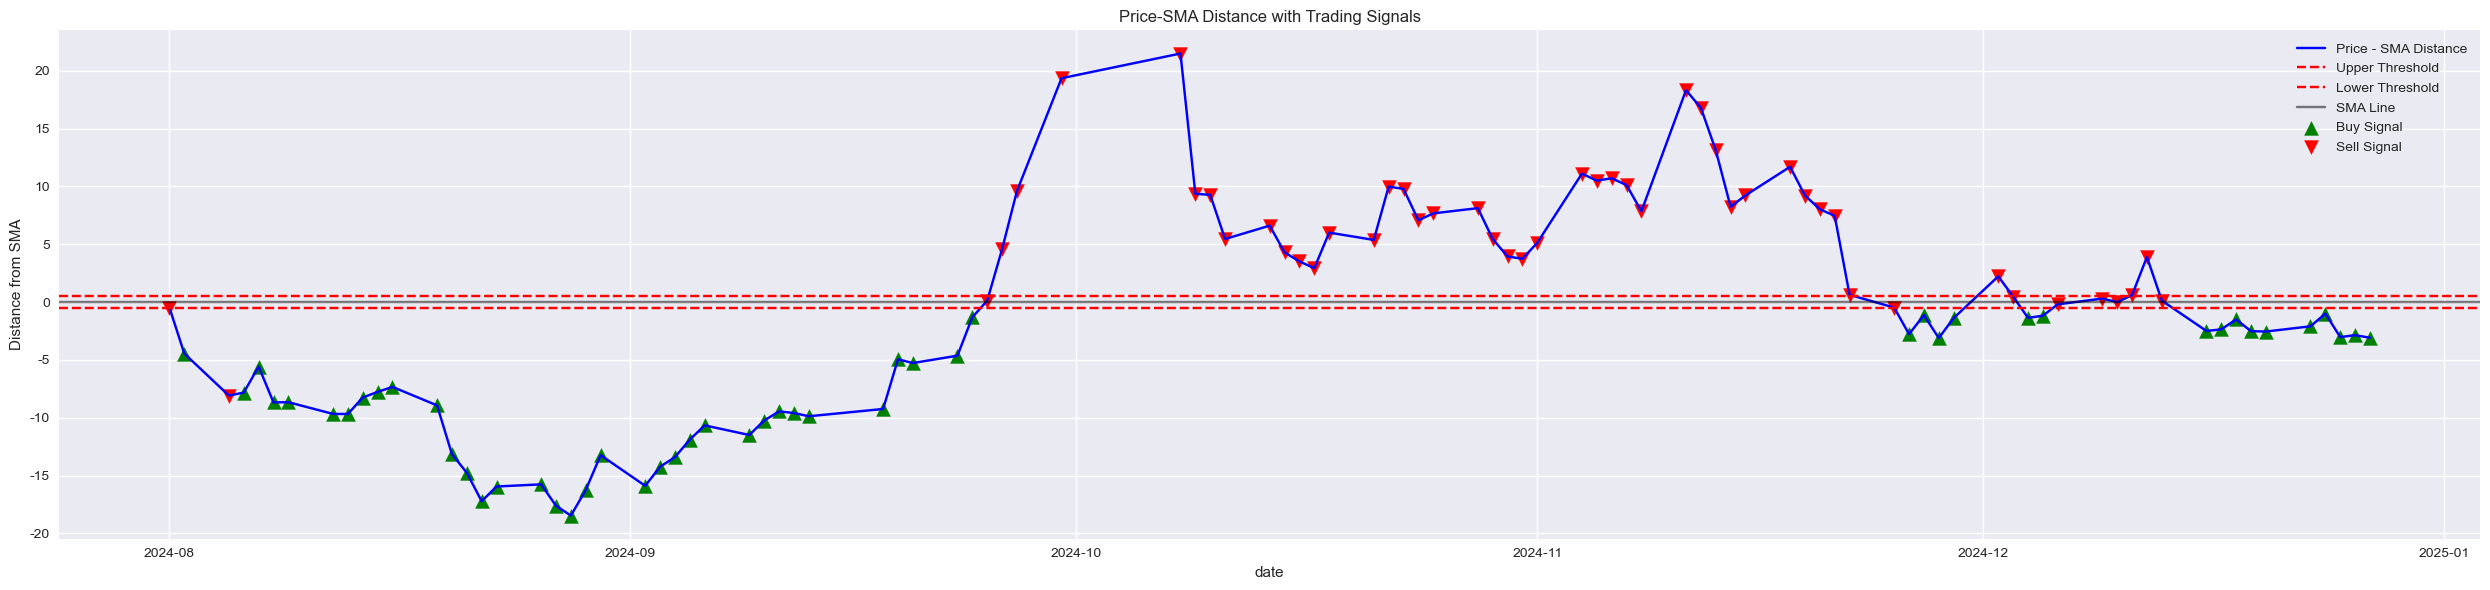

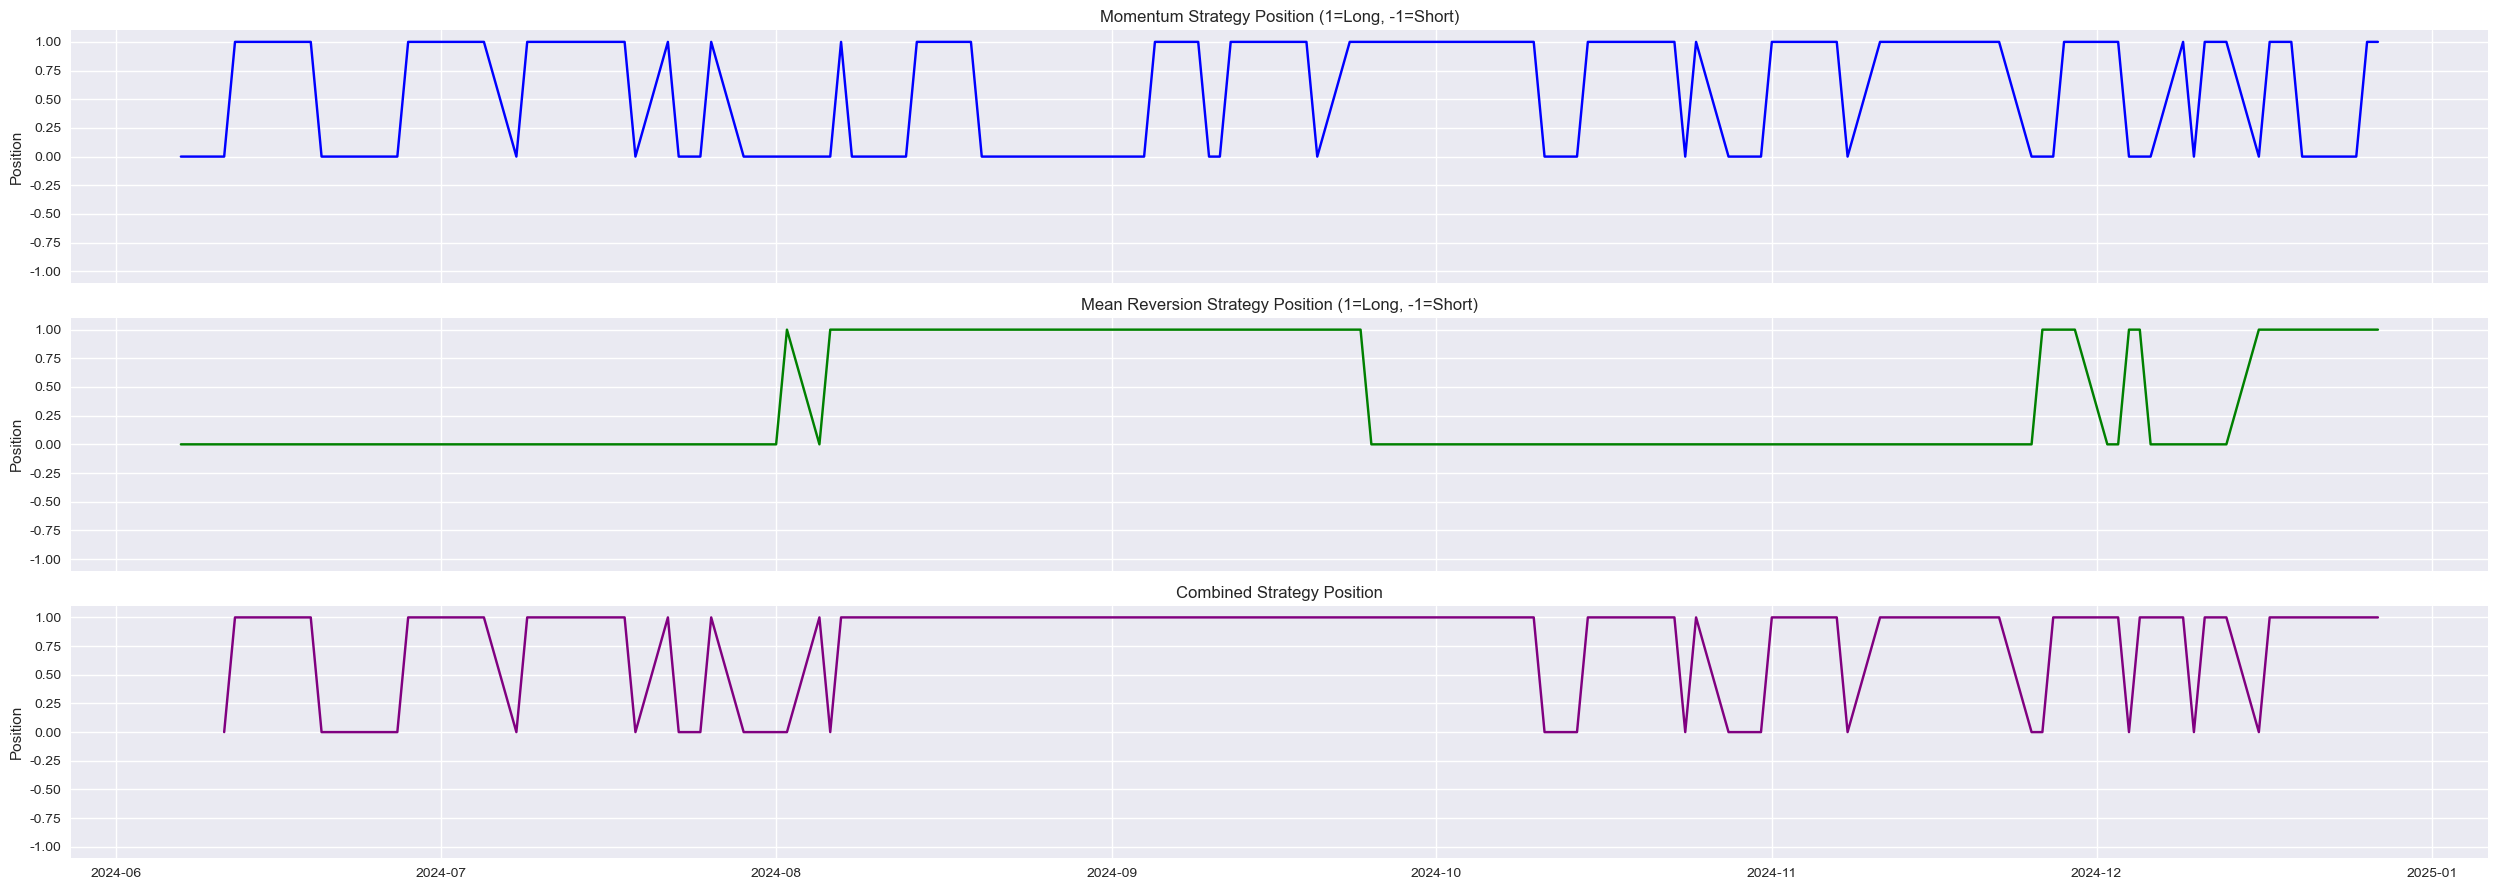

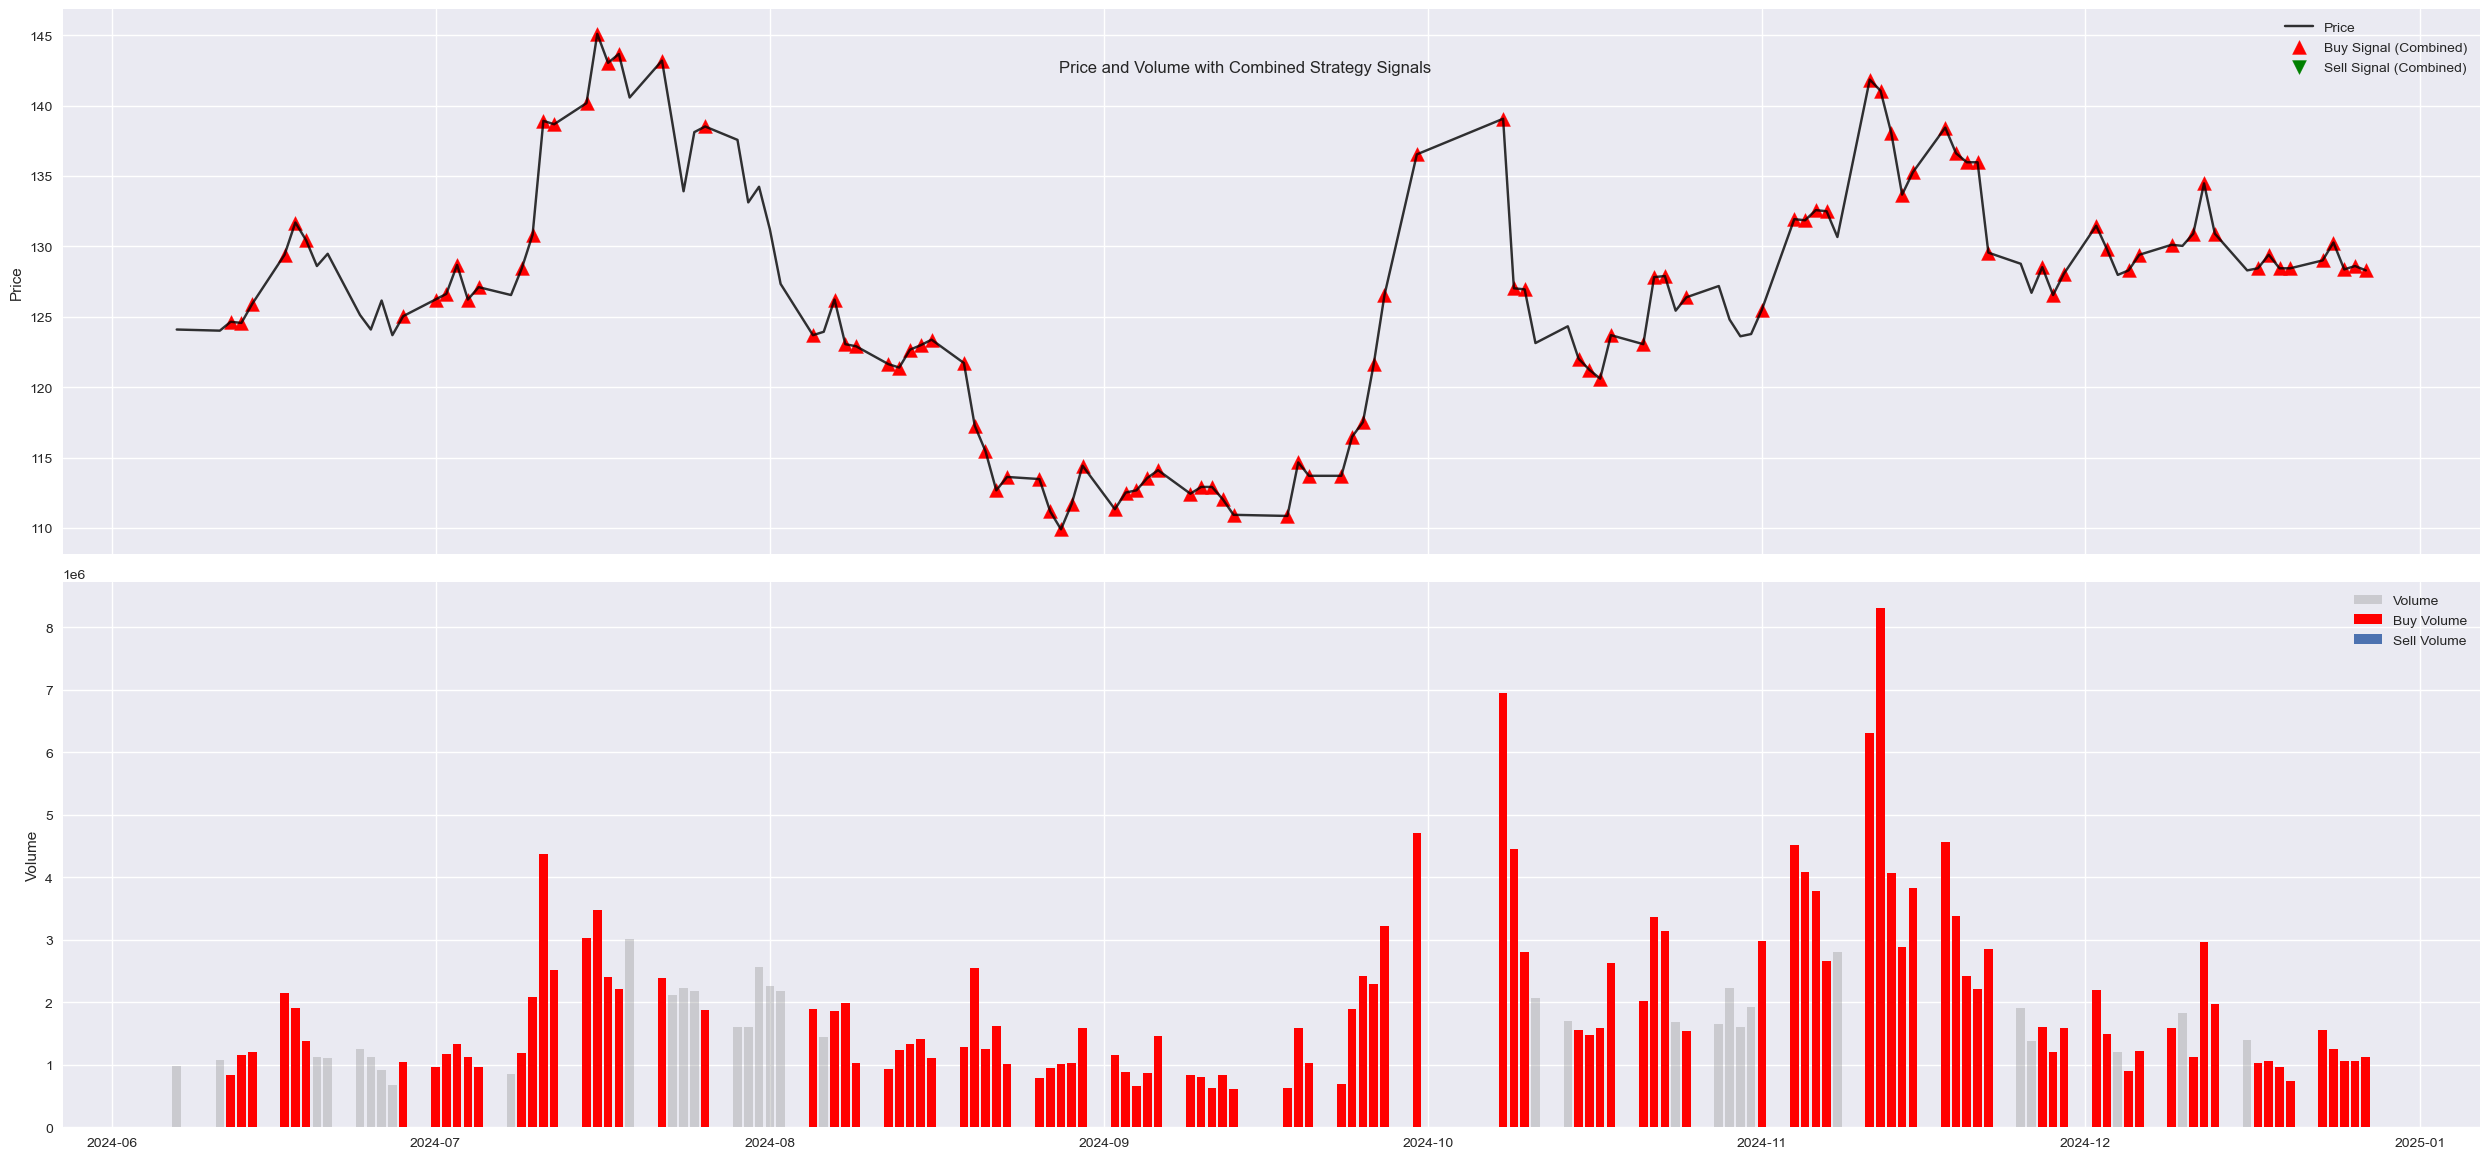

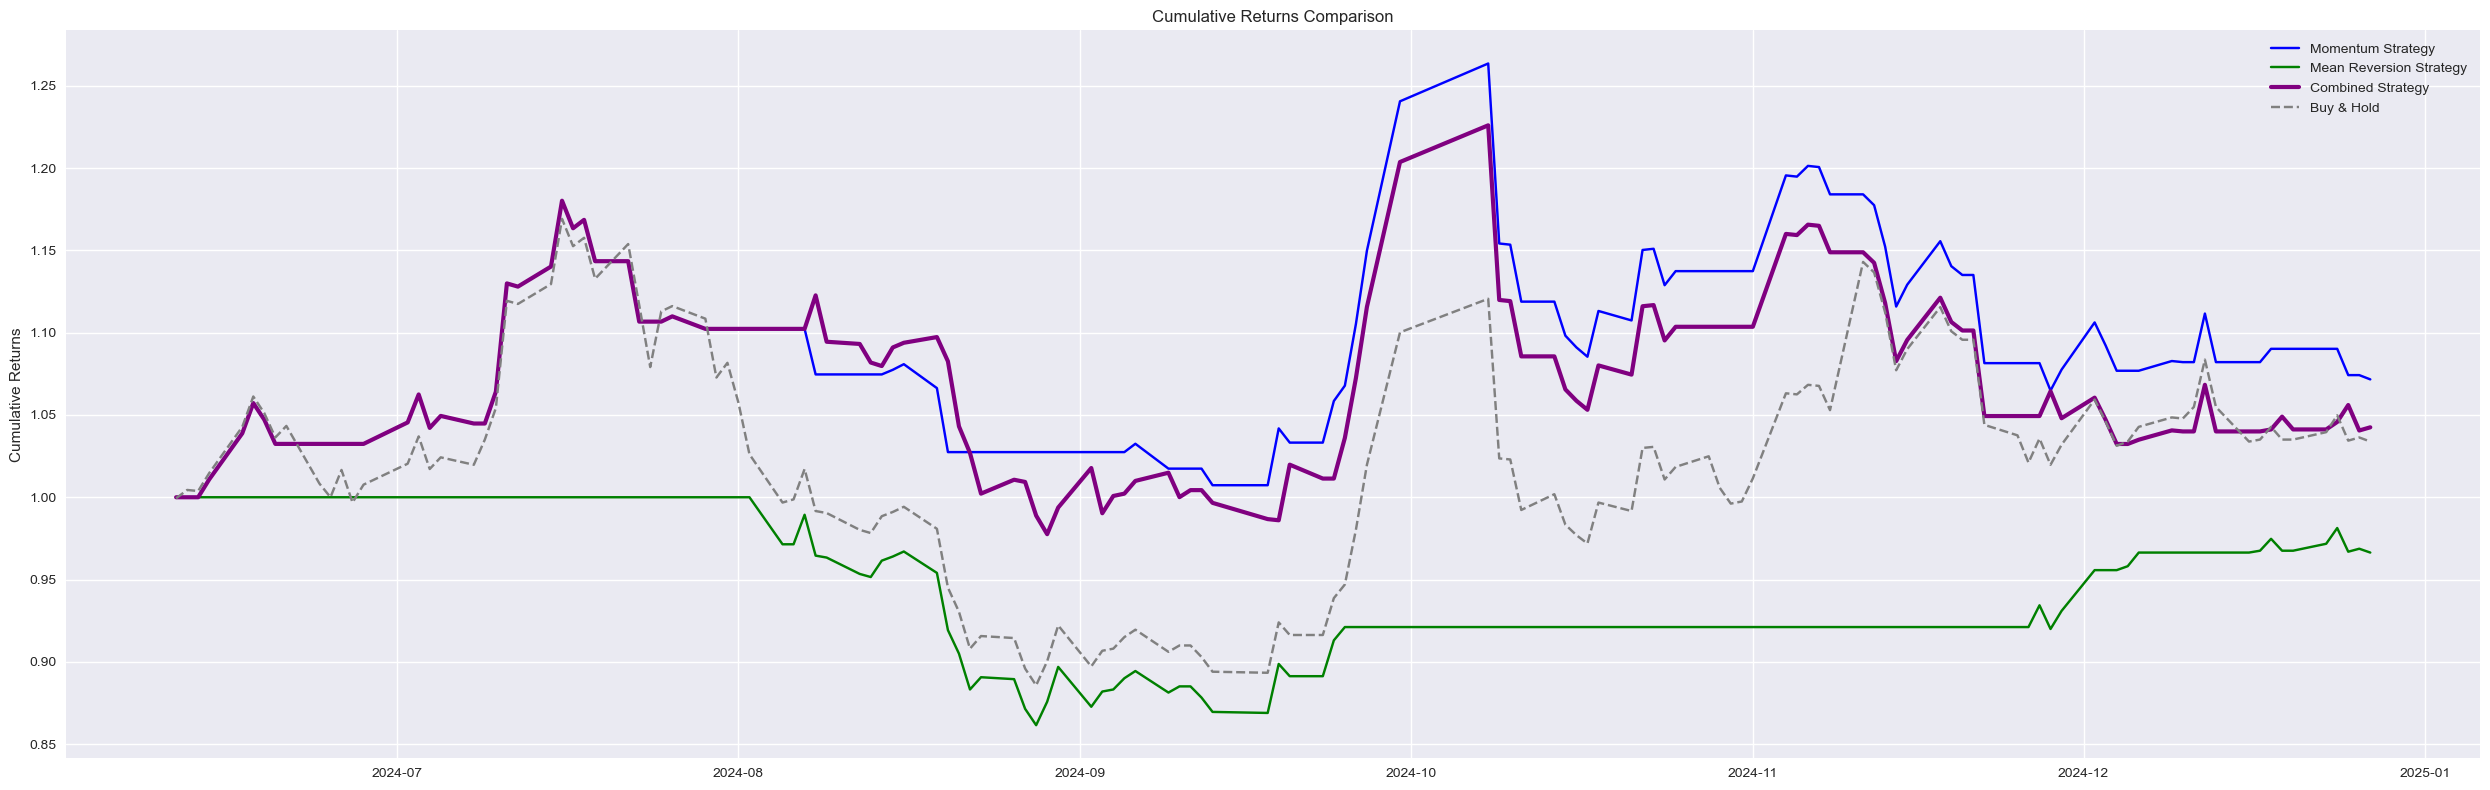

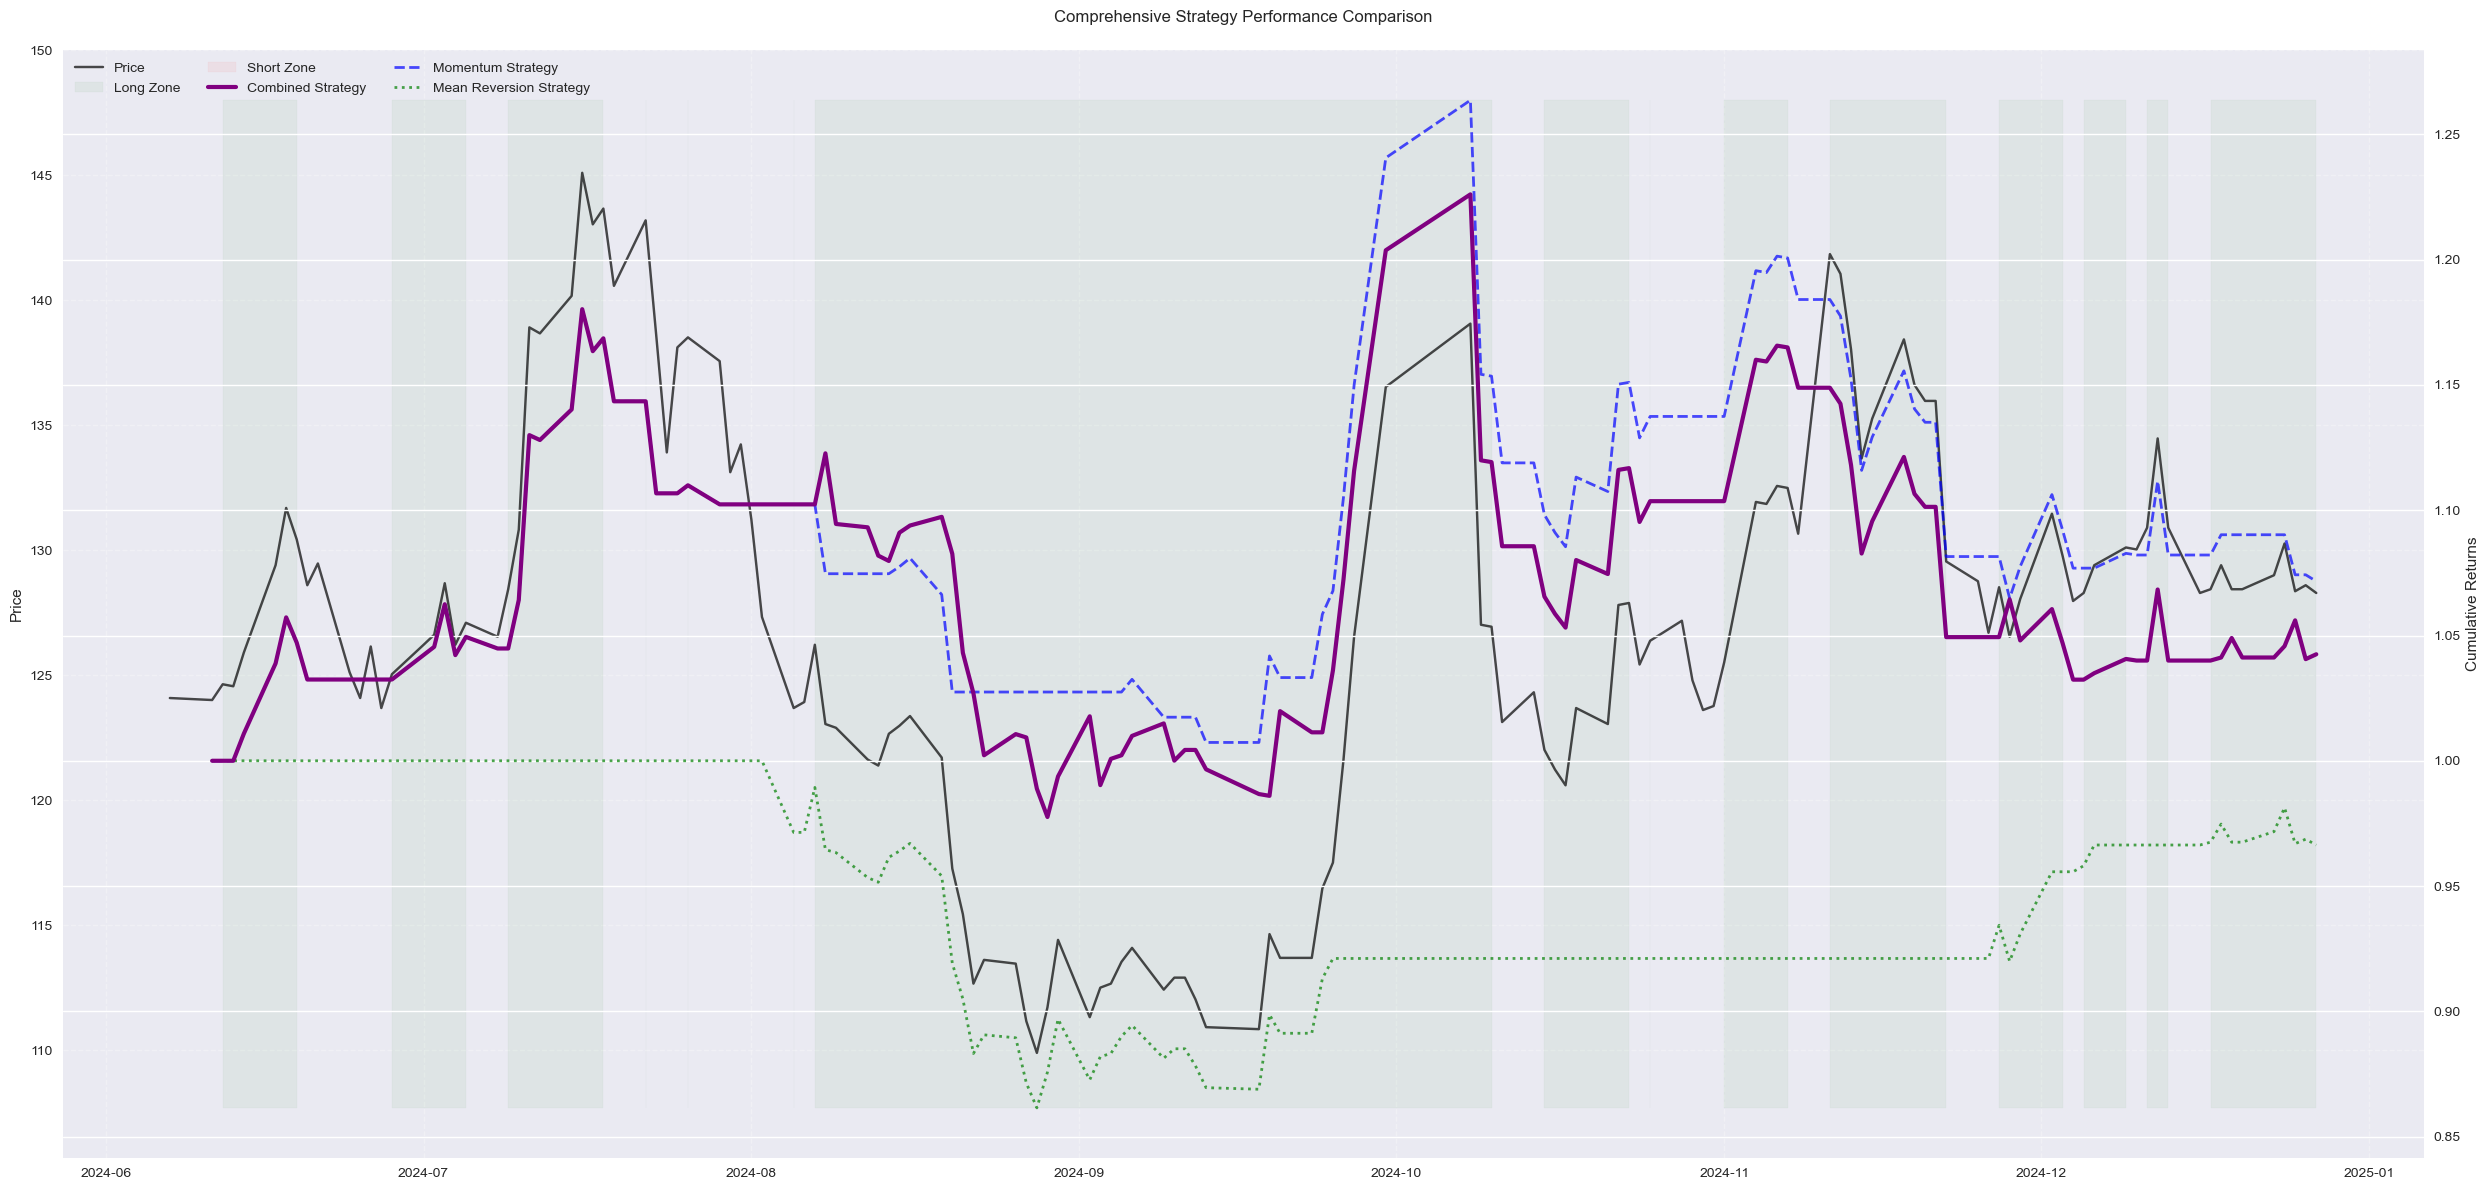

<Figure size 2500x800 with 0 Axes>

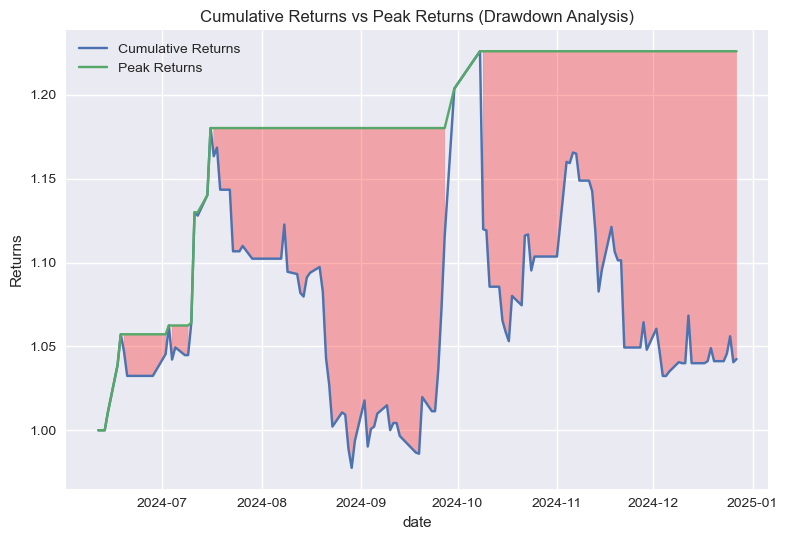


Performance Metrics:
                 Mean  StdDev  Sharpe  TotalReturn  MaxDrawdown
Momentum       0.0005  0.0183  0.0277       0.0692       0.1988
MeanReversion -0.0002  0.0090 -0.0278      -0.0342       0.1386
Combined       0.0003  0.0189  0.0160       0.0416       0.2027


In [12]:
automas_by_mean(train, window_size, decay_factor, Default_Strategy,mean_reversion_params)
gra_analyze(train)

**操盘指导**

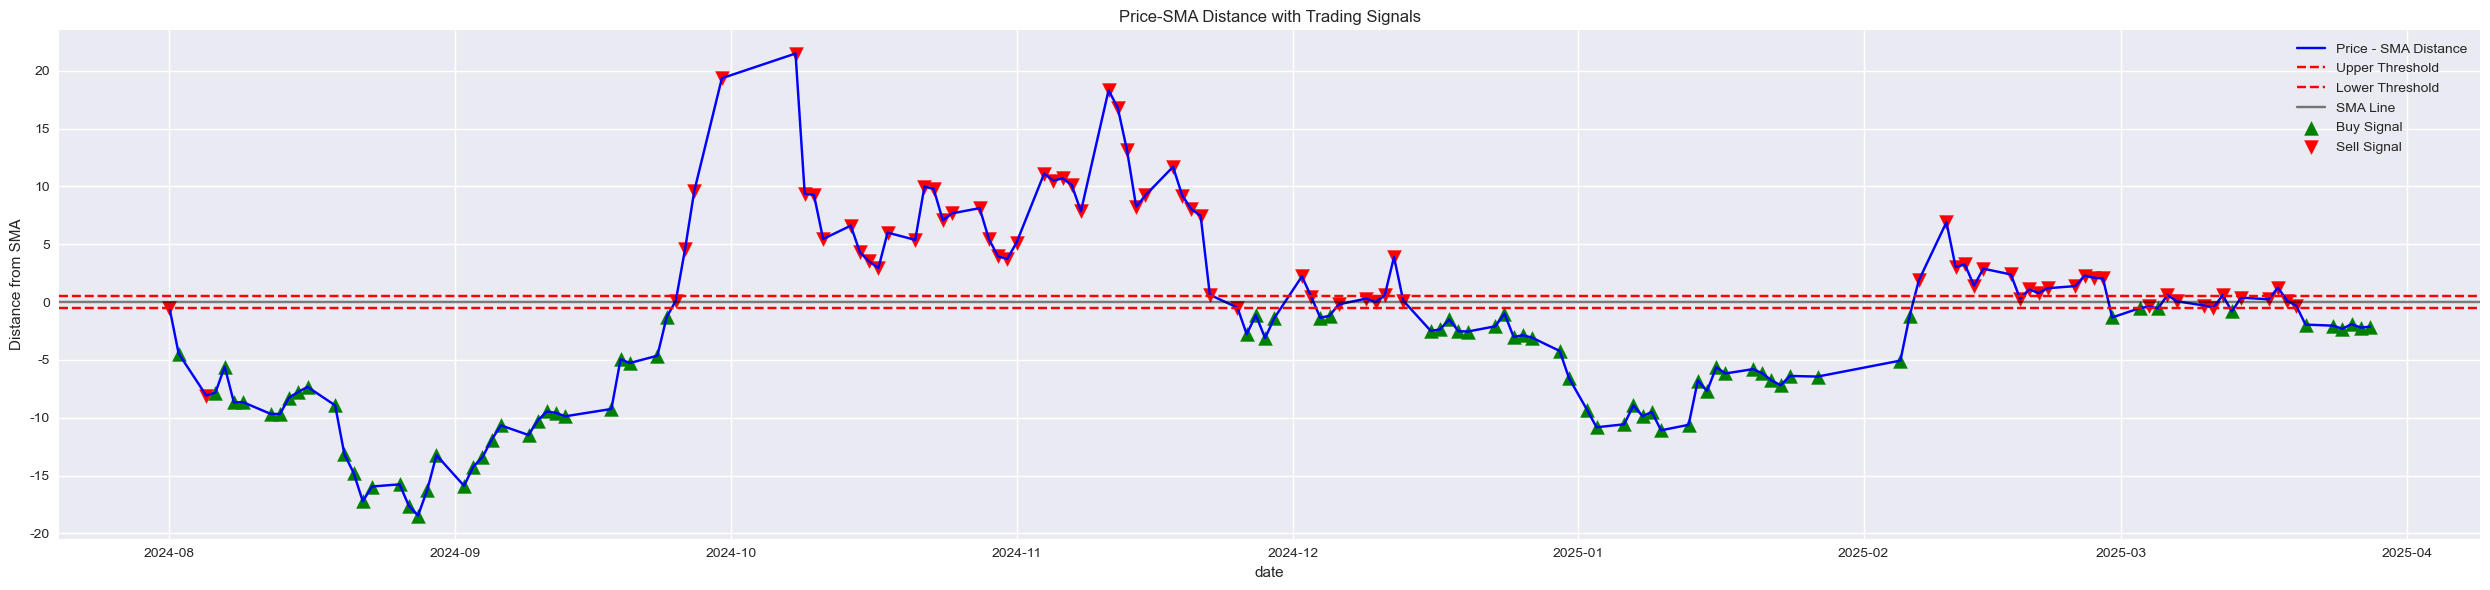

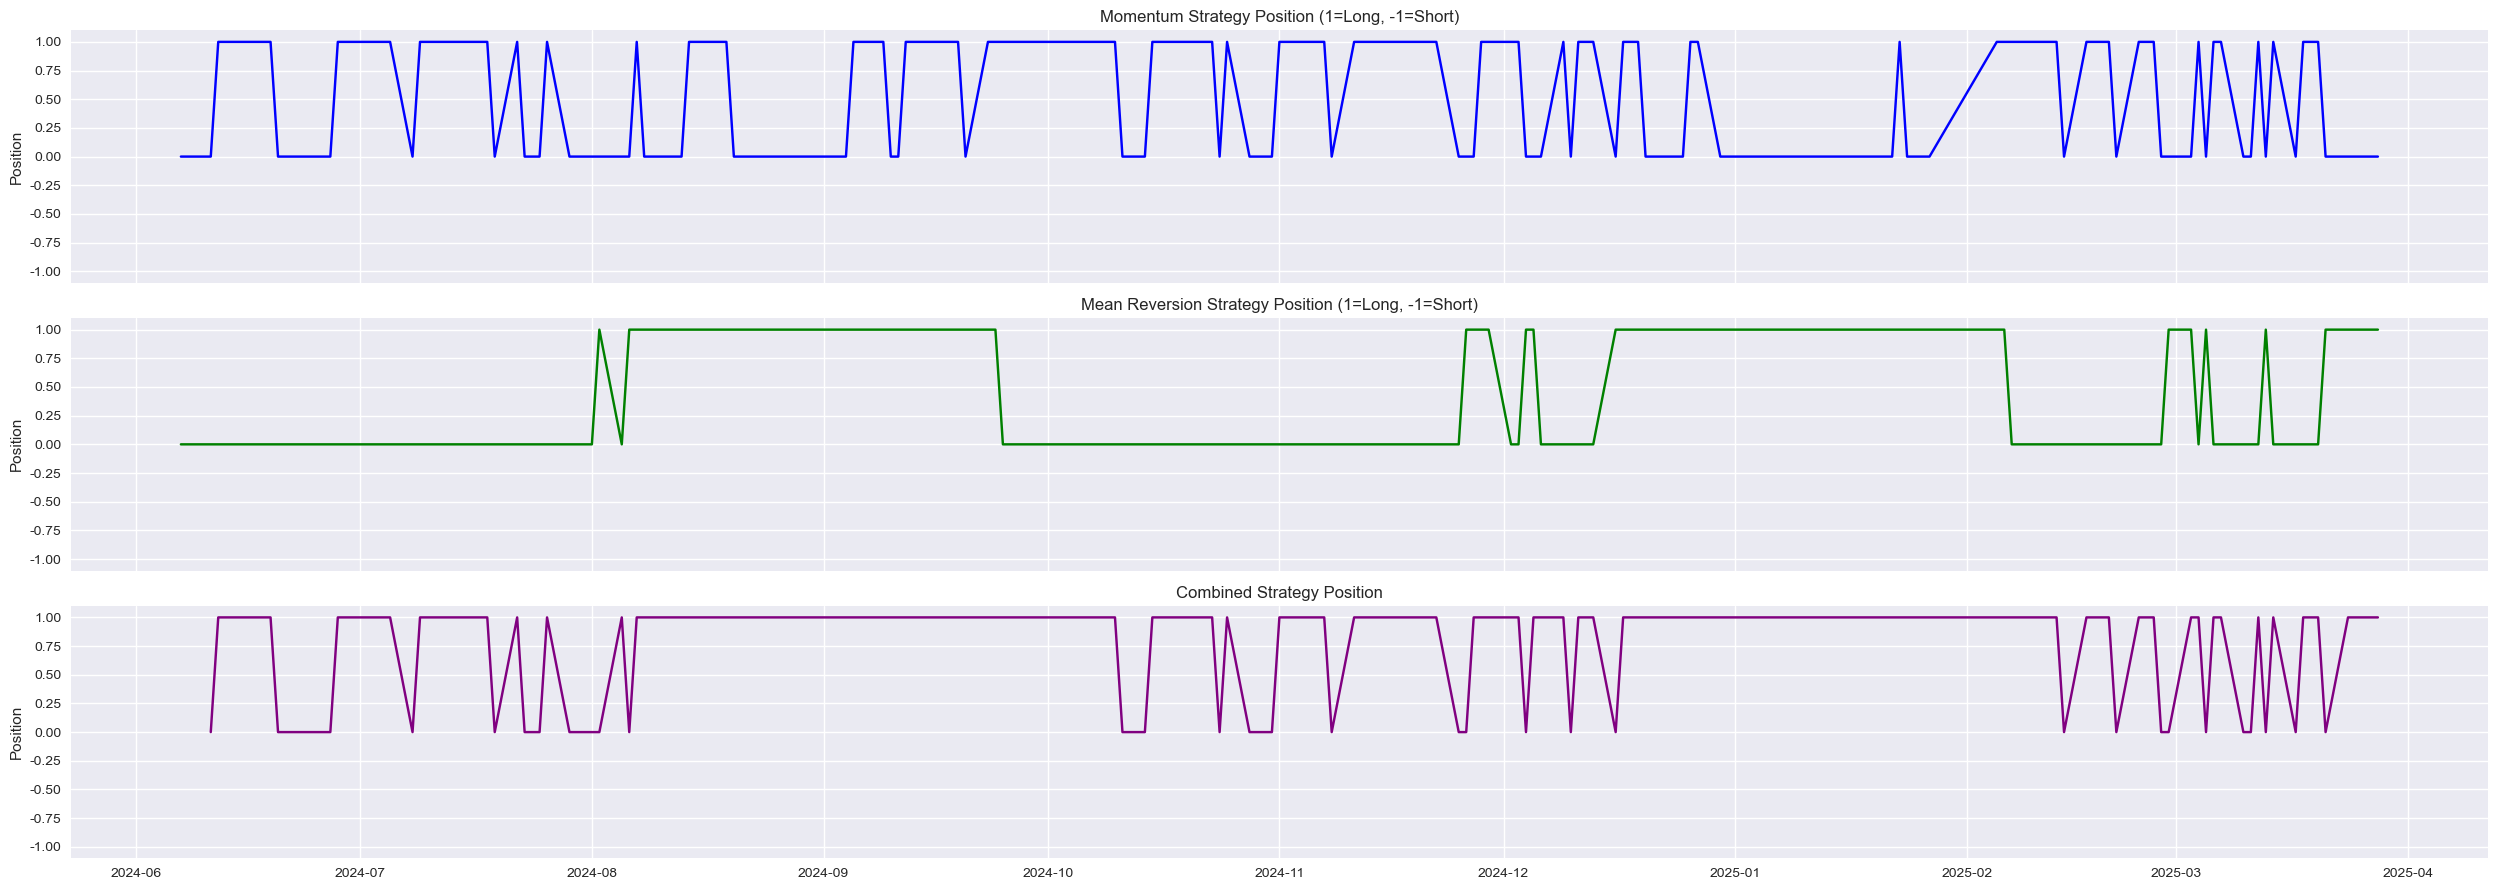

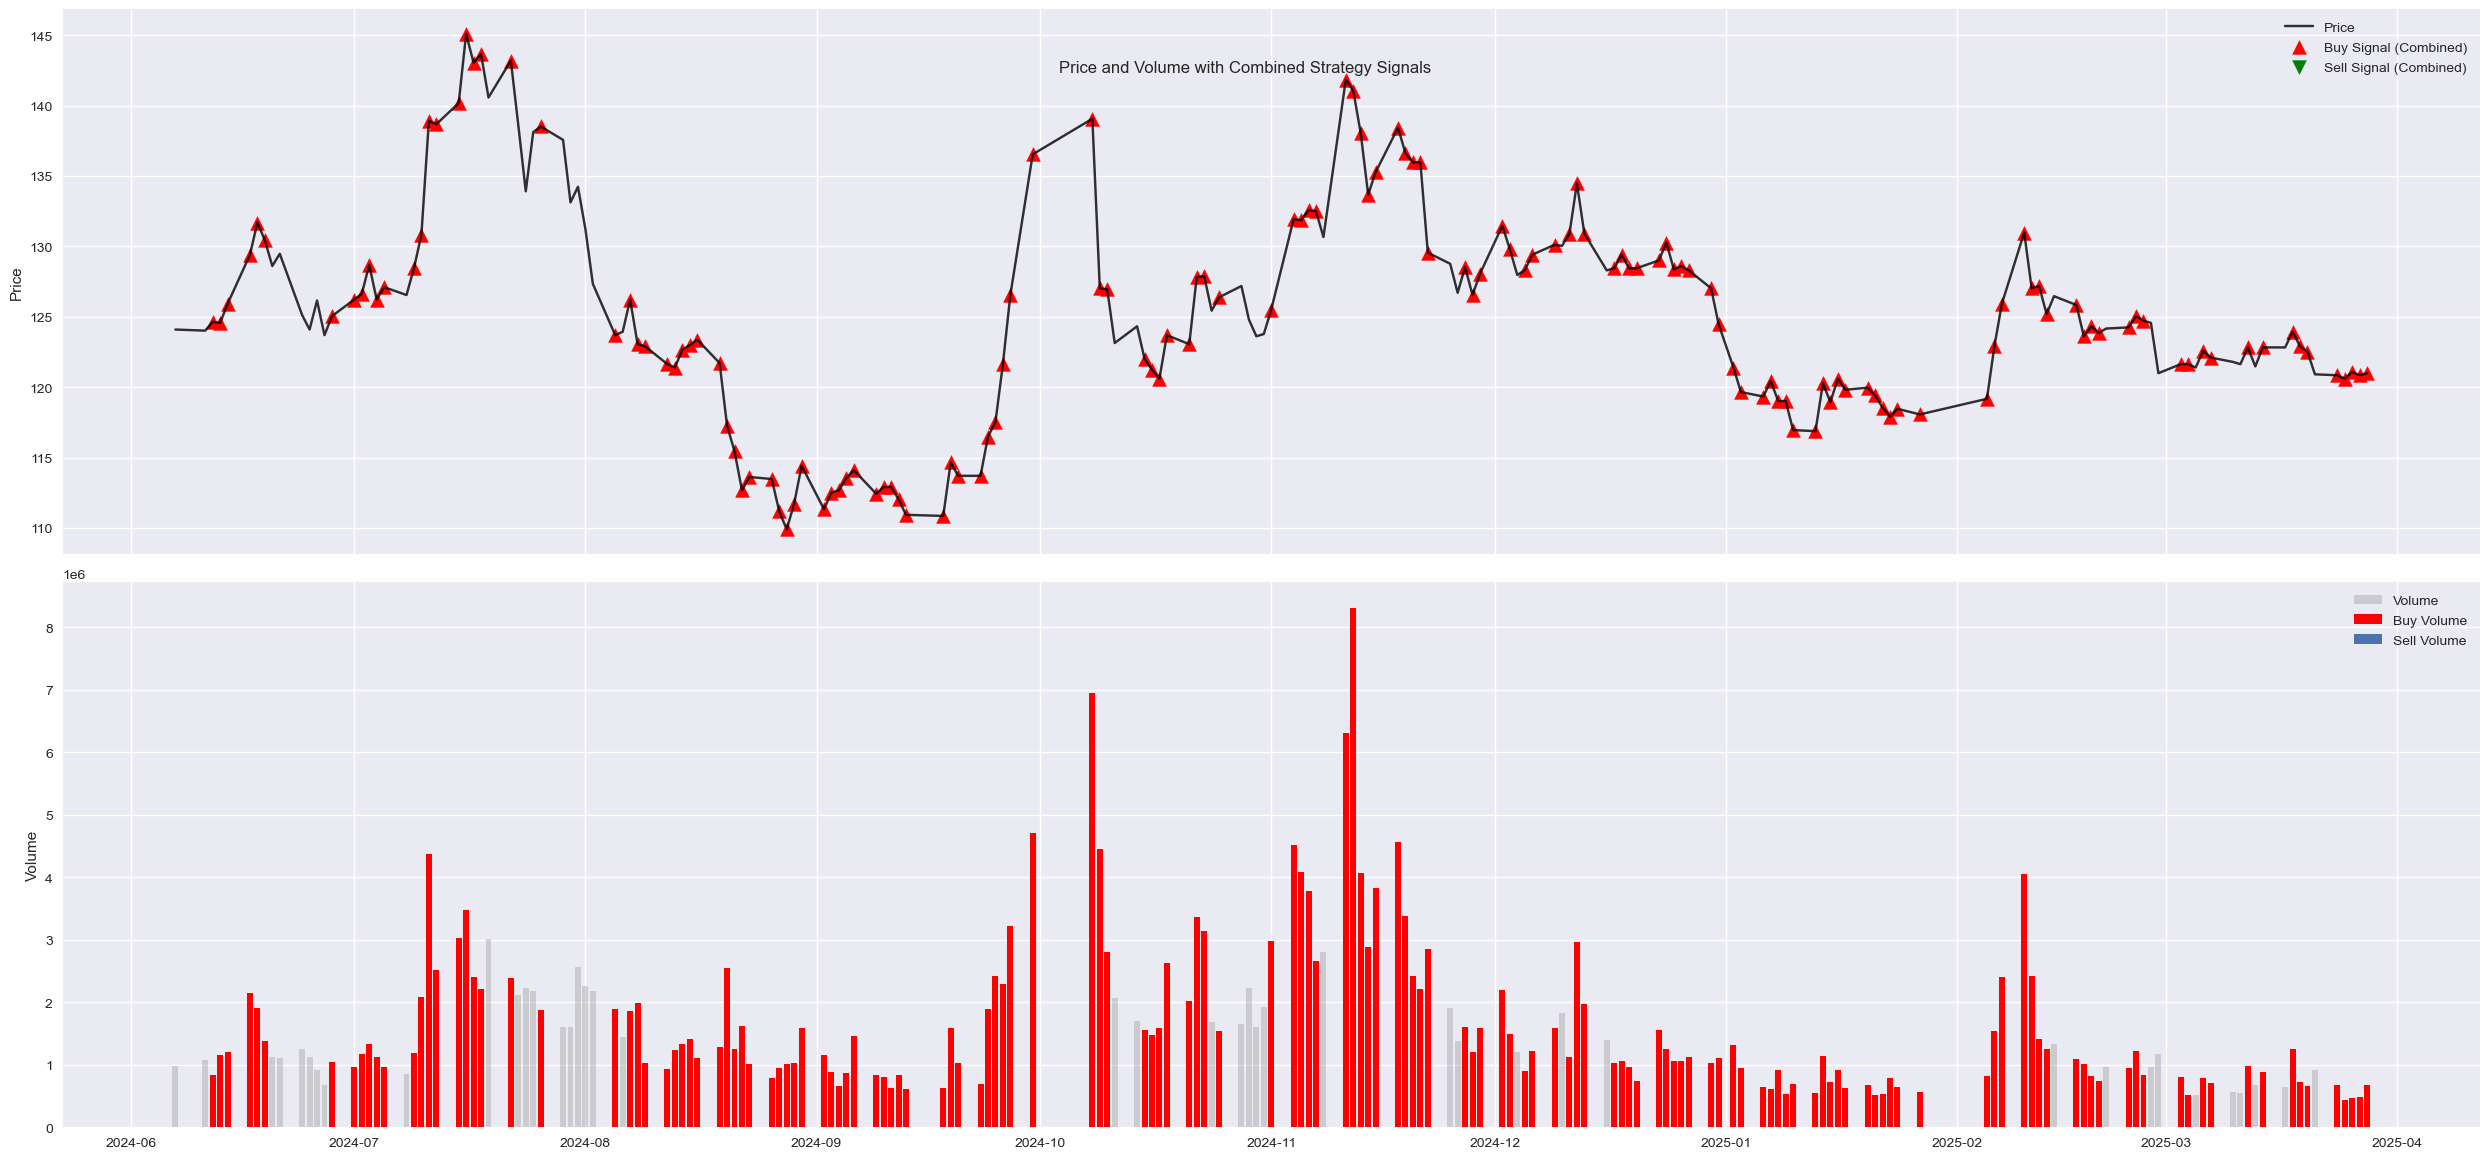

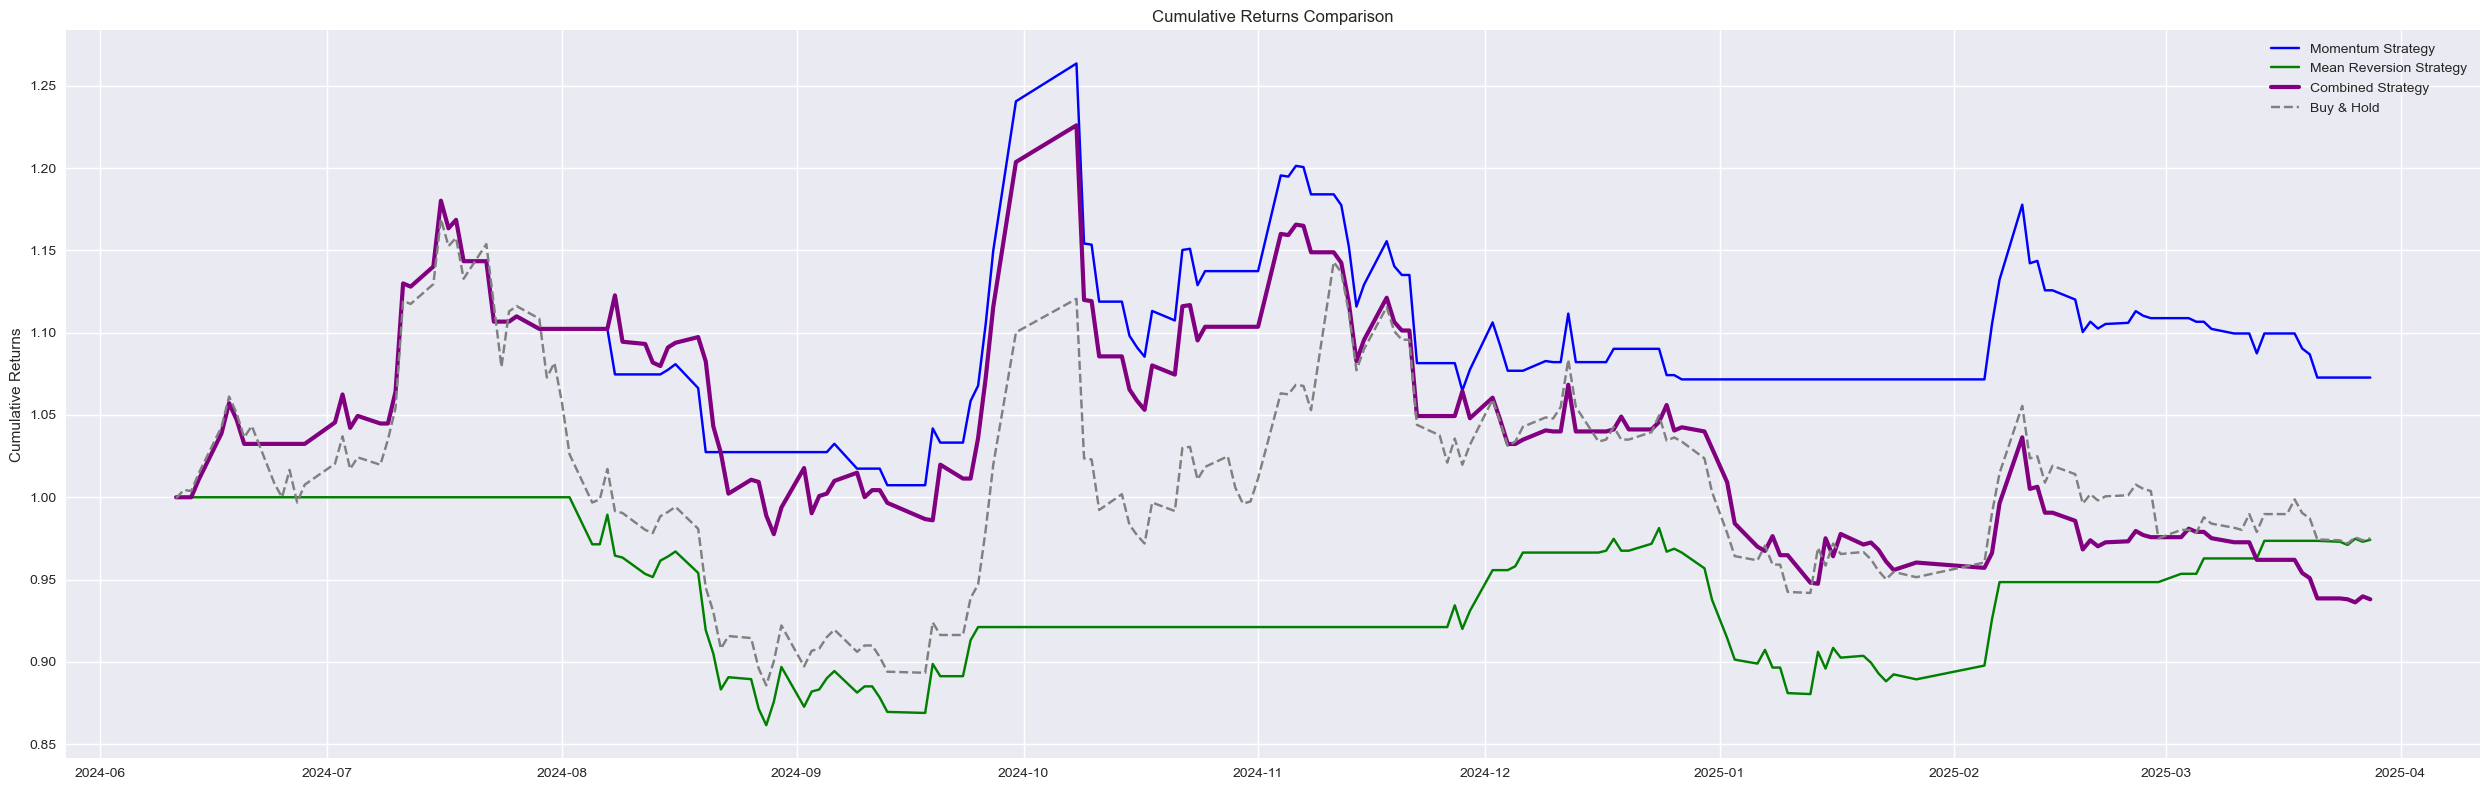

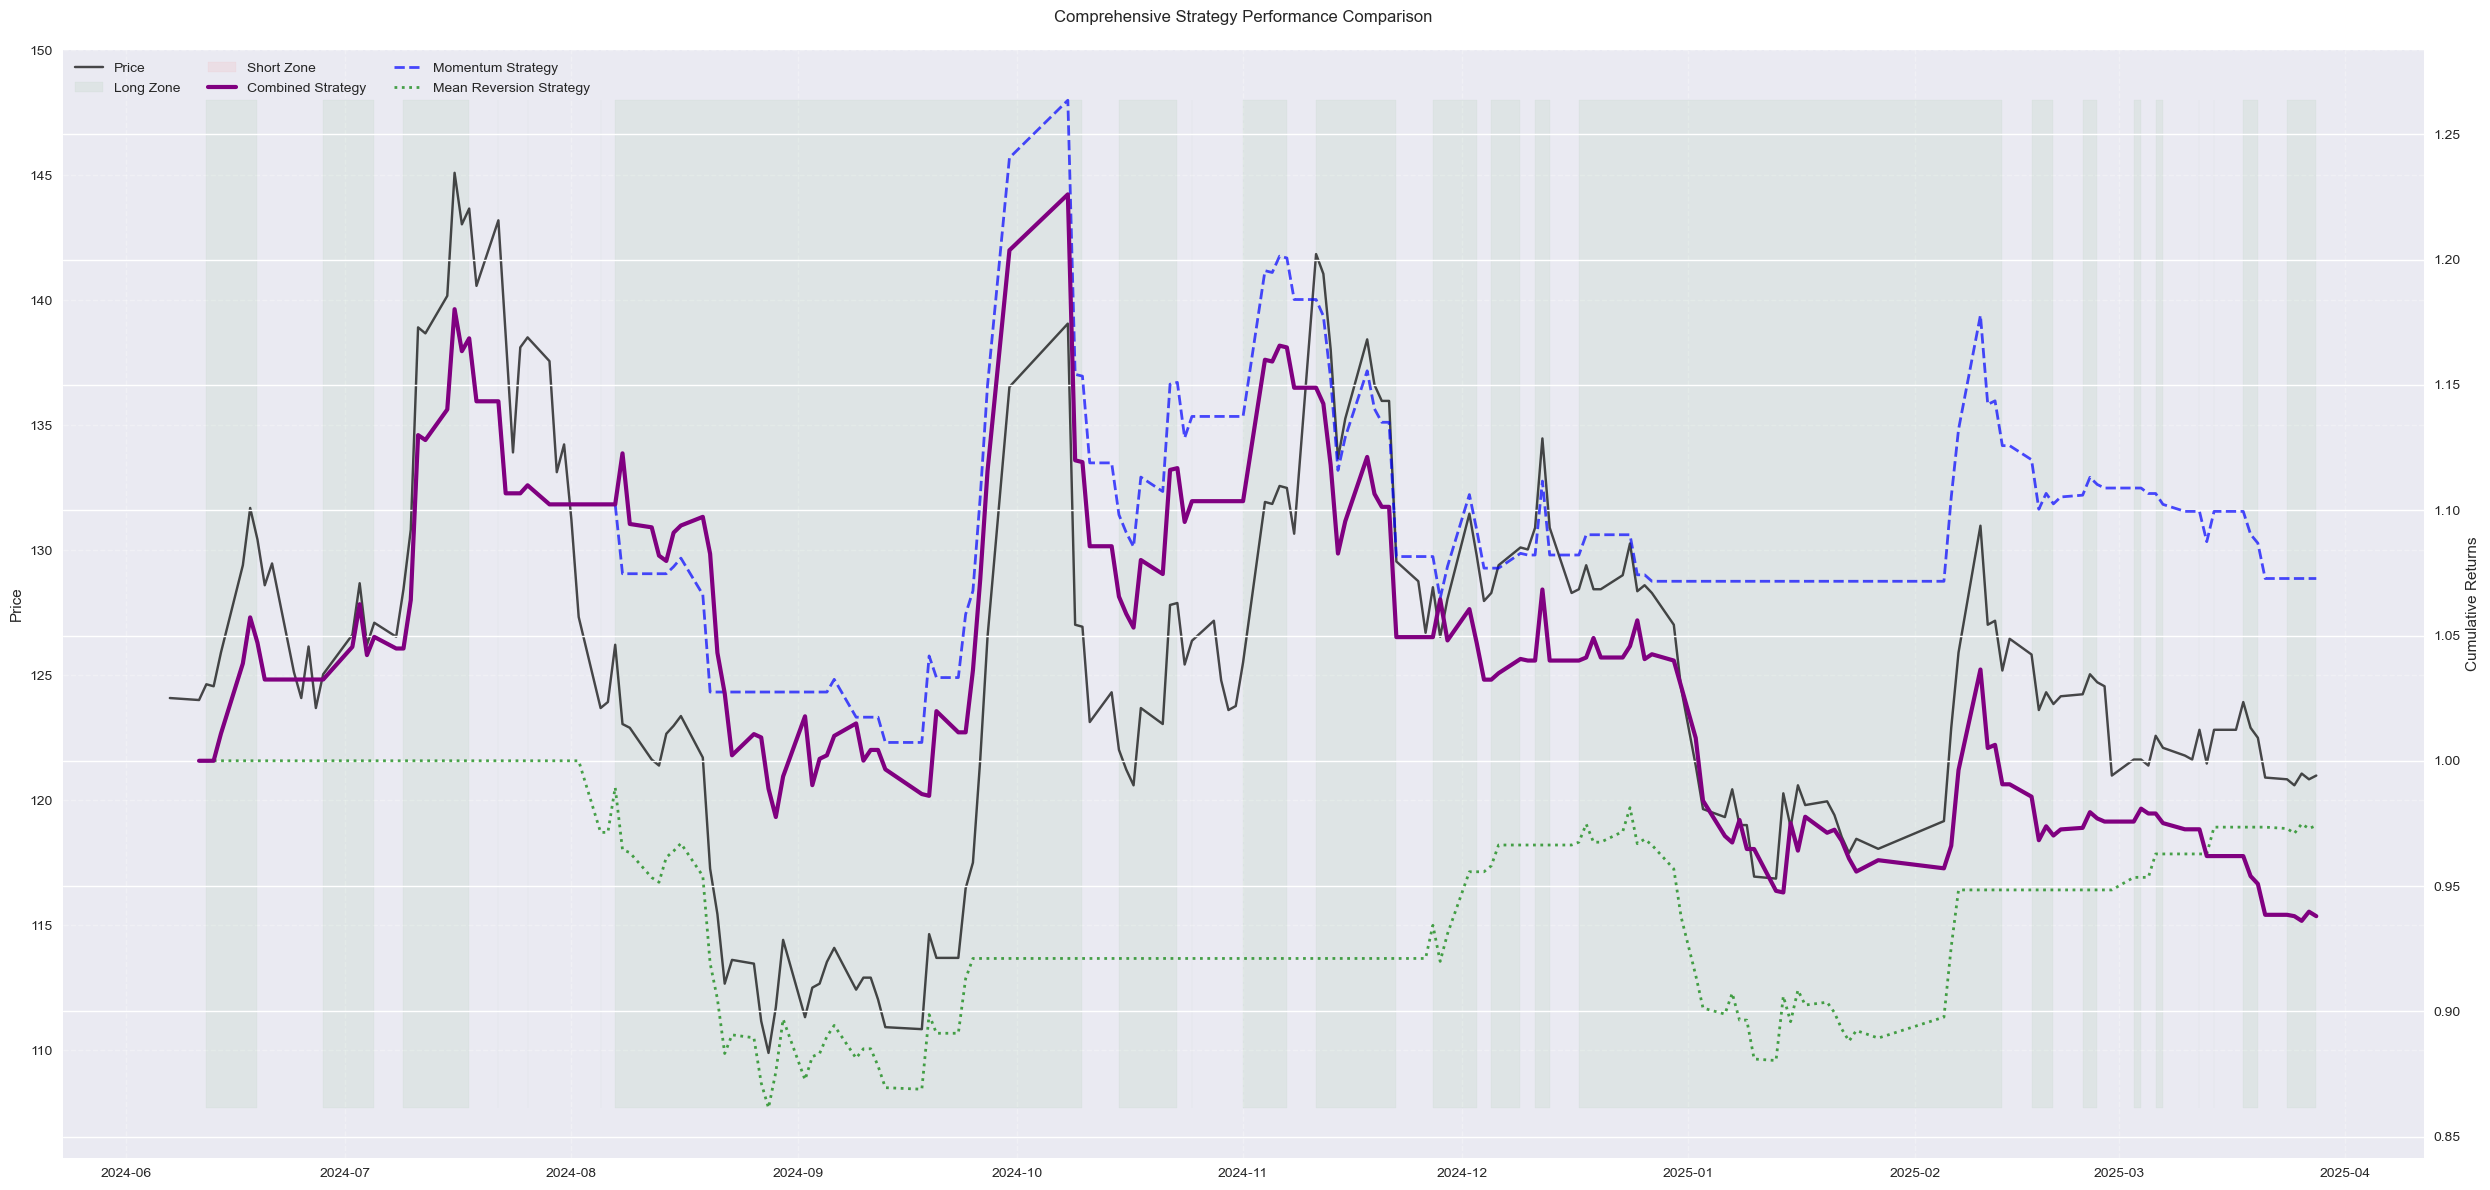

<Figure size 2500x800 with 0 Axes>

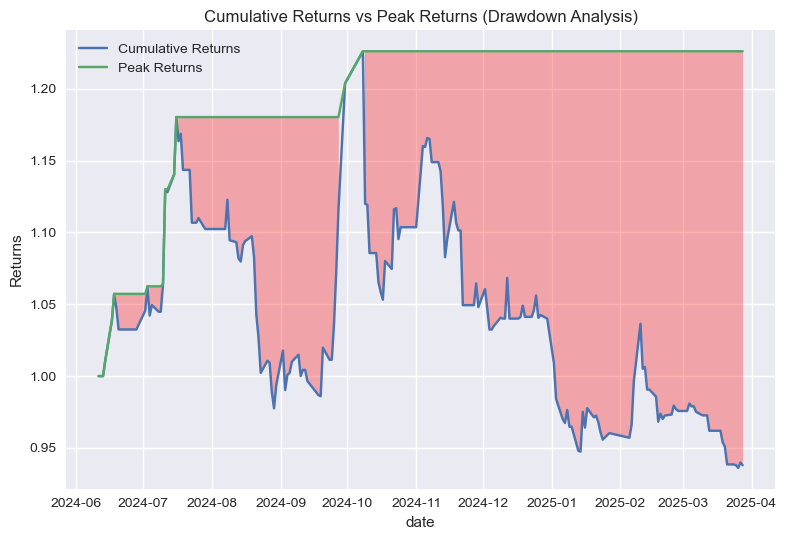


Performance Metrics:
                 Mean  StdDev  Sharpe  TotalReturn  MaxDrawdown
Momentum       0.0004  0.0161  0.0223       0.0702       0.1988
MeanReversion -0.0001  0.0091 -0.0148      -0.0262       0.1386
Combined      -0.0003  0.0171 -0.0192      -0.0640       0.2900


In [13]:
automas_by_mean(data, window_size, decay_factor, Default_Strategy,mean_reversion_params)
gra_analyze(data)


最后5日交易指令：


,price,combined_position,signal
date,,,
2025-03-24,120.84,1.0,HOLD
2025-03-25,120.60,1.0,HOLD
2025-03-26,121.07,1.0,HOLD
2025-03-27,120.84,1.0,HOLD
2025-03-28,120.99,1.0,HOLD


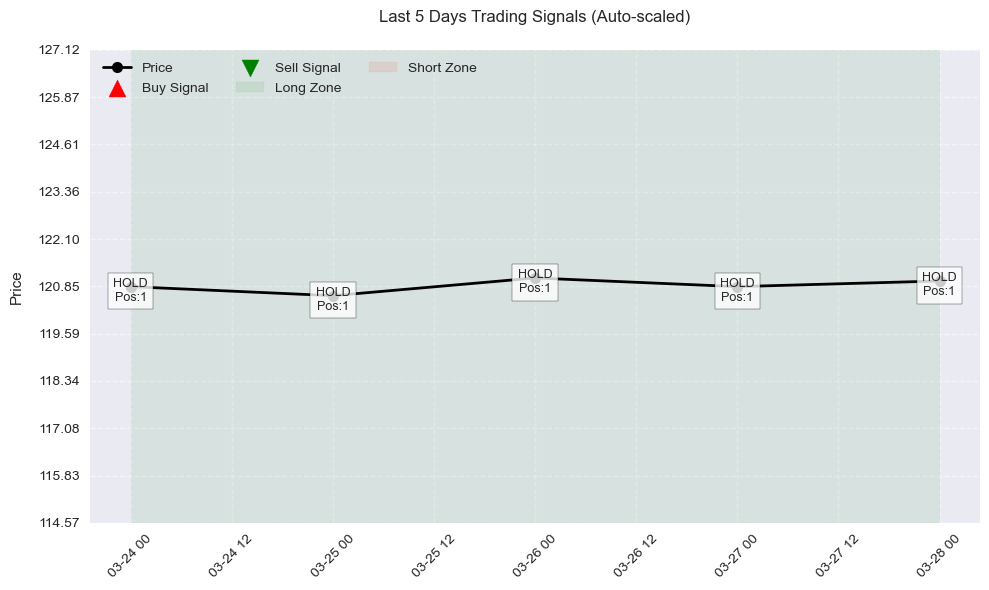

In [14]:
action(data)